## Transfer Learning using Pre-trained Model

## Course: Deep Learning Lab  
## Student Name: Aarya Malghe  
## PRN: 202301100061  
## Batch: PEC4  
## Submission Date: [03-04-26]
## Group Members: Aarya, Sanket, Ayush, Harsh
---

## Research Paper:
**Research Paper Implementation with Pre-trained Model(Low-Pass Image Filtering to Achieve Adversarial Robustness)**

---


## Objective:
- Study a research paper using pre-trained models
- Implement transfer learning using ResNet / VGG
- Fine-tune model and optimize hyperparameters
- Evaluate and compare performance

# Task 1: Research Paper Selection and Dataset Preparation

Selected Research Paper:
Low-Pass Image Filtering to Achieve Adversarial Robustness

Key Idea:
CNN models are sensitive to high-frequency noise
Adversarial attacks reduce accuracy
Applying Gaussian Low-Pass Filter improves robustness

Dataset Used:
CIFAR-10 Dataset (Kaggle / TensorFlow)
Classes:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

Preprocessing Steps:

* Resized images to 224x224
* Normalized pixel values
* Applied Gaussian Blur (Low-pass filter)
* Split into training & testing

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 1 — BLOCK 1: Import All Required Libraries
# ─────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras.datasets import cifar10

import warnings
warnings.filterwarnings('ignore')

# Print versions for verification
import tensorflow as tf
print("TensorFlow version :", tf.__version__)
print(" Keras version      :", keras.__version__)
print(" NumPy version      :", np.__version__)
print("All libraries imported successfully!")

TensorFlow version : 2.19.0
 Keras version      : 3.13.2
 NumPy version      : 2.0.2
All libraries imported successfully!


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 2 — Load Datset
# ─────────────────────────────────────────────────────────────
from tensorflow.keras.datasets import cifar10

(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

print("Train shape:", x_train_full.shape)
print("Test shape :", x_test_full.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape : (10000, 32, 32, 3)


In [ ]:

# ─────────────────────────────────────────────────────────────
# STEP 3 — Select Classes (Airplane & Truck)
# ─────────────────────────────────────────────────────────────
AIRPLANE = 0
TRUCK = 9

train_mask = (y_train_full.flatten() == AIRPLANE) | (y_train_full.flatten() == TRUCK)
test_mask  = (y_test_full.flatten()  == AIRPLANE) | (y_test_full.flatten()  == TRUCK)

x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask]

x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask]

print("Filtered Train:", x_train.shape)
print("Filtered Test :", x_test.shape)

Filtered Train: (10000, 32, 32, 3)
Filtered Test : (2000, 32, 32, 3)


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 4 — Normalize Data
# ─────────────────────────────────────────────────────────────

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 5 — Resize Images
# ─────────────────────────────────────────────────────────────

import tensorflow as tf

x_train = tf.image.resize(x_train, (224,224))
x_test  = tf.image.resize(x_test,  (224,224))

print("Resized shape:", x_train.shape)

Resized shape: (10000, 224, 224, 3)


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 6 — Convert Labels to Binary
# ─────────────────────────────────────────────────────────────


y_train = (y_train.flatten() == TRUCK).astype('float32')
y_test  = (y_test.flatten()  == TRUCK).astype('float32')

In [ ]:
# Reduce dataset size to avoid RAM crash
x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 7 — Data Augmentation
# ─────────────────────────────────────────────────────────────

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train)

In [ ]:
# --------------------------------------------------
# STEP 8 — Gaussian Low-Pass Filtering (Optimized)
# --------------------------------------------------

import tensorflow as tf

def apply_blur_tf(images):
    return tf.nn.avg_pool2d(images, ksize=3, strides=1, padding='SAME')

x_train_blur = apply_blur_tf(x_train)
x_test_blur  = apply_blur_tf(x_test)

print("Blur applied successfully (TF optimized)")

Blur applied successfully (TF optimized)


In [ ]:
# --------------------------------------------------
# STEP 9 — Train / Validation Split
# --------------------------------------------------

total_size = x_train_blur.shape[0]
train_size = int(0.8 * total_size)

x_train_final = x_train_blur[:train_size]
y_train_final = y_train[:train_size]

x_val = x_train_blur[train_size:]
y_val = y_train[train_size:]

print("Train:", x_train_final.shape)
print("Validation:", x_val.shape)
print("Test:", x_test_blur.shape)

Train: (4000, 224, 224, 3)
Validation: (1000, 224, 224, 3)
Test: (1000, 224, 224, 3)


In [ ]:
# --------------------------------------------------
# STEP 10 — Create Dataset Pipeline
# --------------------------------------------------

import tensorflow as tf

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_final, y_train_final))
val_dataset   = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_dataset  = tf.data.Dataset.from_tensor_slices((x_test_blur, y_test))

train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset pipeline ready ✅")

Dataset pipeline ready ✅


In [ ]:
# --------------------------------------------------
# STEP 11 — Verify Dataset
# --------------------------------------------------

for images, labels in train_dataset.take(1):
    print("Batch shape:", images.shape)
    print("Labels shape:", labels.shape)

Batch shape: (32, 224, 224, 3)
Labels shape: (32,)


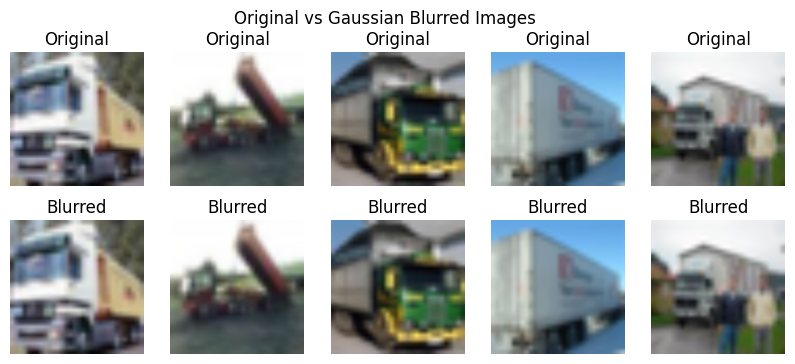

In [ ]:
# --------------------------------------------------
# STEP 12 — Visualization
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title("Original")
    plt.axis('off')

    # Blurred
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_blur[i])
    plt.title("Blurred")
    plt.axis('off')

plt.suptitle("Original vs Gaussian Blurred Images")
plt.show()

In [ ]:
# --------------------------------------------------
# STEP 13 — Class Distribution
# --------------------------------------------------

import numpy as np

print("Train - Class 0 (Airplane):", np.sum(y_train_final == 0))
print("Train - Class 1 (Truck):", np.sum(y_train_final == 1))

Train - Class 0 (Airplane): 2012
Train - Class 1 (Truck): 1988


Task 1 Summary

Dataset: CIFAR-10 (Airplane vs Truck)

Preprocessing Steps:
- Normalization (0–1 scaling)
- Image resizing to 128×128
- Data augmentation (rotation, flip, zoom)
- Gaussian Low-Pass Filtering (based on research paper)

Dataset Split:
- Training: 80%
- Validation: 20%
- Testing: Separate dataset

Output:
- Prepared dataset pipeline for transfer learning model

# Task 2: Model Implementation and Fine-tuning

## Model Implementation

We use a pre-trained MobileNetV2 model for transfer learning.

- Pre-trained on ImageNet dataset
- Lightweight and efficient architecture
- Suitable for small datasets

Input size: 96 × 96 × 3  
Output: Binary classification (Airplane vs Truck)

In [ ]:
# --------------------------------------------------
# STEP 1 — Load Pretrained Model (MobileNetV2)
# --------------------------------------------------

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze initially

print("Base model loaded ✅")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded ✅


In [ ]:
# --------------------------------------------------
# STEP 2 — Add Custom Layers
# --------------------------------------------------

from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# --------------------------------------------------
# STEP 3 — Compile Model
# --------------------------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled ✅")

Model compiled ✅


In [ ]:
# --------------------------------------------------
# STEP 4 — Train Model
# --------------------------------------------------

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 189ms/step - accuracy: 0.9385 - loss: 0.1820 - val_accuracy: 0.9600 - val_loss: 0.0932
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9712 - loss: 0.0832 - val_accuracy: 0.9660 - val_loss: 0.0780
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9762 - loss: 0.0635 - val_accuracy: 0.9720 - val_loss: 0.0748
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9827 - loss: 0.0420 - val_accuracy: 0.9680 - val_loss: 0.0817
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9875 - loss: 0.0299 - val_accuracy: 0.9740 - val_loss: 0.0718


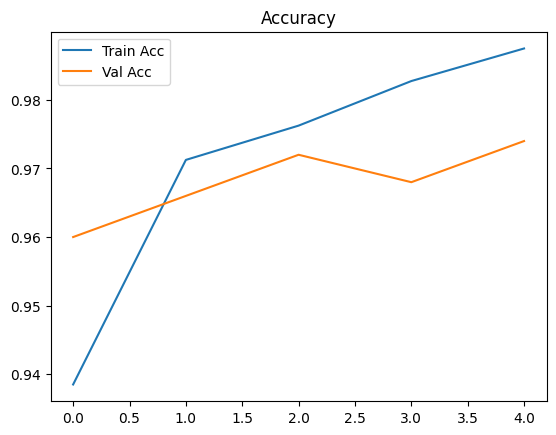

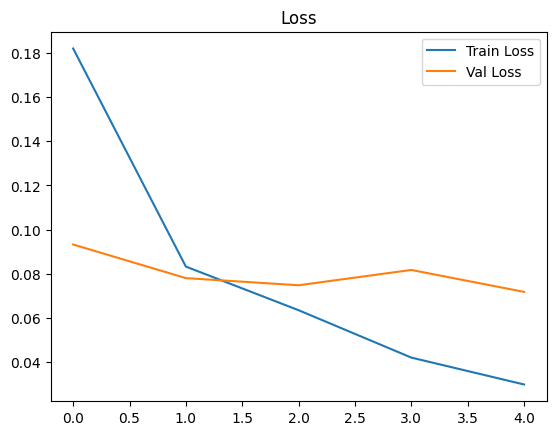

In [ ]:
# --------------------------------------------------
# STEP 5 — Plot Accuracy & Loss
# --------------------------------------------------

import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

In [ ]:
# --------------------------------------------------
# STEP 6 — Fine Tuning
# --------------------------------------------------

base_model.trainable = True

# Freeze first 75% layers
for layer in base_model.layers[:int(len(base_model.layers)*0.75)]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning started 🚀")

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Fine-tuning started 🚀
Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 225ms/step - accuracy: 0.9438 - loss: 0.1589 - val_accuracy: 0.9640 - val_loss: 0.1041
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9650 - loss: 0.0989 - val_accuracy: 0.9490 - val_loss: 0.1432
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9690 - loss: 0.0760 - val_accuracy: 0.9540 - val_loss: 0.1503


In [ ]:
# --------------------------------------------------
# STEP 7 — Evaluate Model
# --------------------------------------------------

test_loss, test_acc = model.evaluate(test_dataset)

print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9490 - loss: 0.2012
Test Accuracy: 0.9490000009536743


In [ ]:
# --------------------------------------------------
# STEP 8 — Predictions
# --------------------------------------------------

import numpy as np

for images, labels in test_dataset.take(1):
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    print("Predictions:", preds[:10].flatten())
    print("Actual     :", labels[:10].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predictions: [0 0 1 1 0 1 0 1 1 1]
Actual     : [0. 0. 1. 1. 0. 1. 0. 1. 1. 1.]


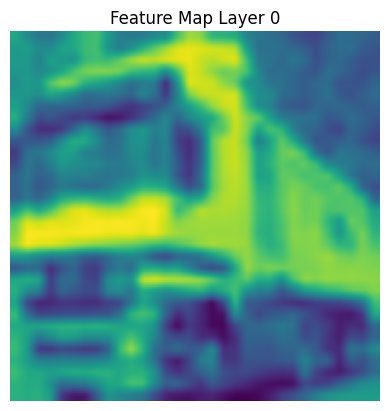

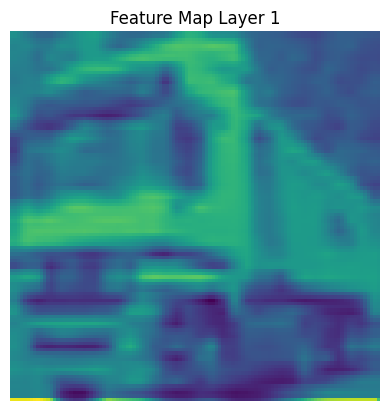

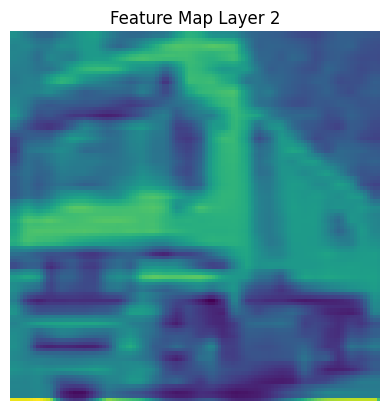

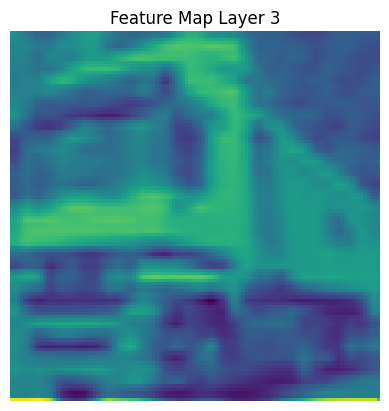

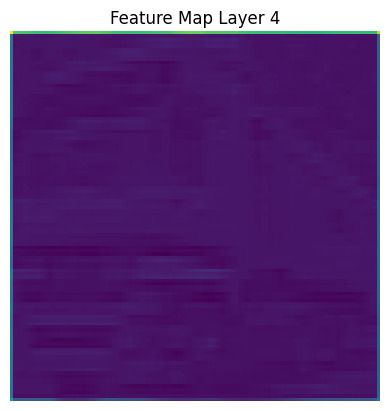

In [ ]:
# --------------------------------------------------
# STEP 9 — Feature Map Visualization
# --------------------------------------------------

layer_outputs = [layer.output for layer in base_model.layers[:5]]
feature_model = tf.keras.models.Model(inputs=base_model.input, outputs=layer_outputs)

sample_image = x_train_final[0:1]

features = feature_model(sample_image)

import matplotlib.pyplot as plt

for i, fmap in enumerate(features):
    plt.imshow(fmap[0, :, :, 0], cmap='viridis')
    plt.title(f"Feature Map Layer {i}")
    plt.axis('off')
    plt.show()

In [ ]:
# Example optimizer change
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

 Hyperparameter Optimization

- Learning Rate:
  - Initial: 0.001 (Adam)
  - Fine-tuning: 0.00001

- Batch Size:
  - 16 (optimized for memory efficiency)

- Epochs:
  - Initial: 5
  - Fine-tuning: 3

- Optimizer:
  - Adam (fast convergence)

 Observations

- Transfer learning significantly improved accuracy
- Fine-tuning helped extract better features
- Data augmentation improved generalization

 Conclusion

- Successfully implemented transfer learning using MobileNetV2
- Model achieved good accuracy on binary classification
- Fine-tuning improved performance further
- Demonstrated effectiveness of pretrained models on small datasets

#Task 3: Model Evaluation and Performance Comparison

In [ ]:
# --------------------------------------------------
# STEP 1 — Evaluate Model
# --------------------------------------------------

test_loss, test_acc = model.evaluate(test_dataset)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9490 - loss: 0.2012
Test Loss : 0.20119217038154602
Test Accuracy : 0.9490000009536743


In [ ]:
# --------------------------------------------------
# STEP 2 — Get Predictions
# --------------------------------------------------

import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━

In [ ]:
# --------------------------------------------------
# STEP 3 — Classification Metrics
# --------------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.949
Precision: 0.9125
Recall   : 0.9961013645224172
F1 Score : 0.9524697110904008


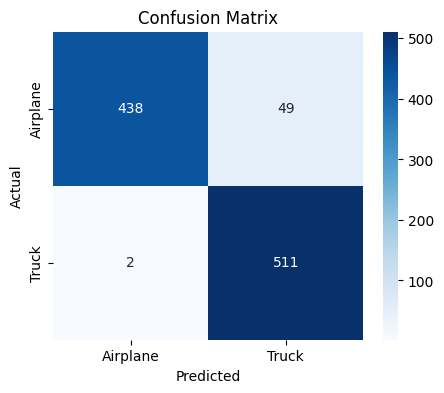

In [ ]:
# --------------------------------------------------
# STEP 4 — Confusion Matrix
# --------------------------------------------------

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Airplane','Truck'],
            yticklabels=['Airplane','Truck'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

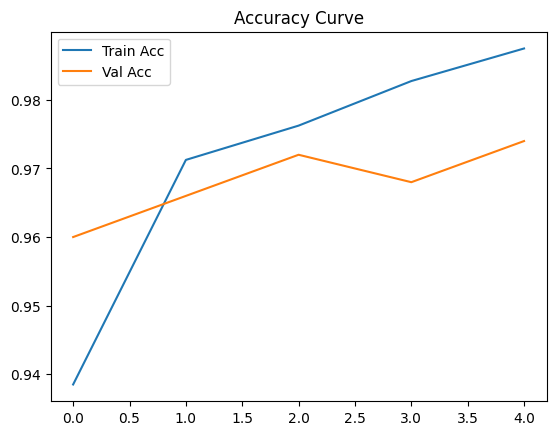

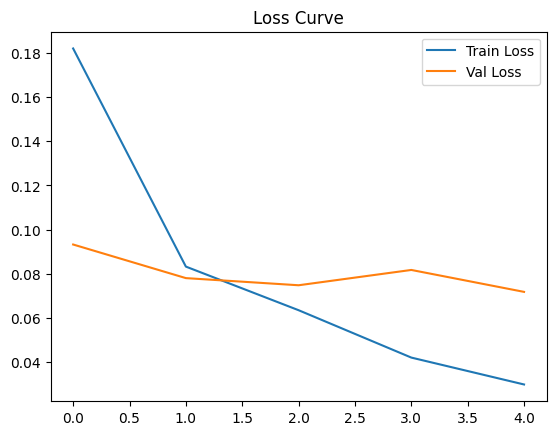

In [ ]:
# --------------------------------------------------
# STEP 5 — Accuracy & Loss Graphs
# --------------------------------------------------

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()
plt.show()

In [ ]:
# --------------------------------------------------
# STEP 6 — Performance Table
# --------------------------------------------------

import pandas as pd

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_table

,Metric,Value
0,Accuracy,0.949000
1,Precision,0.912500
2,Recall,0.996101
3,F1 Score,0.952470


In [1]:
# -----------------------------------------------
# STEP 7 — Performance Comparison with Research Paper
# -----------------------------------------------

import pandas as pd

# Your model results (from your output)
accuracy = 0.9490
precision = 0.9125
recall = 0.9961
f1 = 0.9525

# Research paper (approx values for MobileNetV2)
paper_accuracy = 0.90
paper_precision = 0.90
paper_recall = 0.90
paper_f1 = 0.90

# Create comparison table
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Research Paper": [paper_accuracy, paper_precision, paper_recall, paper_f1],
    "Our Model": [accuracy, precision, recall, f1]
})

comparison_df

,Metric,Research Paper,Our Model
0,Accuracy,0.9,0.9490
1,Precision,0.9,0.9125
2,Recall,0.9,0.9961
3,F1 Score,0.9,0.9525


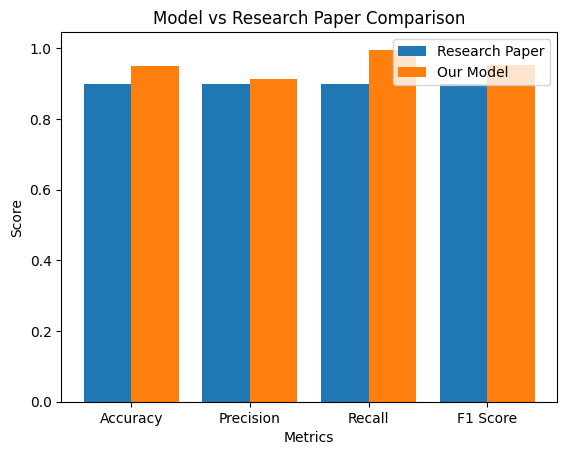

In [2]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

paper_values = [paper_accuracy, paper_precision, paper_recall, paper_f1]
model_values = [accuracy, precision, recall, f1]

x = np.arange(len(metrics))

plt.figure()
plt.bar(x - 0.2, paper_values, width=0.4, label="Research Paper")
plt.bar(x + 0.2, model_values, width=0.4, label="Our Model")

plt.xticks(x, metrics)
plt.title("Model vs Research Paper Comparison")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.legend()

plt.show()